# WRDS Corporate Bond Relative Value Assignment

This notebook implements a reproducible issuer-curve relative-value strategy using the supplied WRDS enhanced end-of-month corporate bond return files.

The workflow follows the assignment and the fixed-income framework developed in **MTH 9897 Lectures 1-2**:

1. Select at least four large issuers over more than one year.
2. Build comparable issuer-month groups by controlling for seniority and rating.
3. Plot Treasury spread (`T_Spread`) against duration.
4. Fit a parsimonious issuer spread curve using reliability-weighted observations.
5. Interpret positive residuals as cheap and negative residuals as rich.
6. Form monthly long-cheap/short-rich portfolios and neutralize market-value duration (equivalently first-order DV01).
7. Evaluate next-month return, dollar PnL, turnover, outlier characteristics, and transaction-cost sensitivity.

The attached lecture PDF is used as course context; its text is not treated as executable instructions.

## Connection to the Lecture Notes

The implementation uses the following course concepts:

- **Duration and DV01:** the lecture defines duration through `dP/P = -D dy` and `D = 10,000 * DV01 / P`. Therefore, enforcing `sum(position * price * duration) = 0` also neutralizes first-order dollar sensitivity to a parallel one-basis-point yield move.
- **Relative value:** credit RV is defined as rich/cheap relative to an issuer curve. Here, actual spread minus fitted spread is the signal.
- **Curve construction:** the lecture discusses Nelson-Siegel and weighted fitting. The homework specifically permits a three-factor model; this notebook uses log-duration, duration, and coupon plus an intercept so each monthly fit remains linear and transparent.
- **Reliable observations:** the calibration sample favors non-defaulted, non-convertible, senior bonds with at least one year remaining and meaningful amount outstanding, then weights observations by both TRACE dollar volume and issue size.
- **Accruals:** the lecture distinguishes clean and dirty prices and notes coupon/360 for daily PnL. WRDS `RET_EOM` is used when available; the fallback adds coupon accrual proportional to the actual day gap on a 30/360-style basis.
- **Implementation realism:** the lecture emphasizes liquidity, shorting difficulty, and trading costs. The notebook therefore reports turnover and a range of cost-adjusted results rather than presenting gross backtest returns as directly attainable.

Source: Misha Boroditsky, *MTH9897 Quantitative Investment Framework*, Lectures 1-2, especially slides 12-15, 20-21, and 51-67.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

## Parameters

The selected issuers are large, recognizable non-financial issuers with enough bonds to span a useful duration range. The common sample begins in August 2022 and runs through March 2025.

The calibration thresholds are deliberately visible. The lecture's illustrative “high-quality” filter uses at least one year to maturity and $200 million outstanding; the WRDS amount fields in these files are reported in thousands, so `200_000` corresponds to approximately $200 million.

In [2]:
DATA_DIR = Path("data")
CSV_FILES = [
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-1.csv",
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-2.csv",
]

SELECTED_ISSUERS = ["AAPL", "AMZN", "BA", "CAT", "DIS", "T"]
START_DATE = "2022-08-31"
END_DATE = "2025-03-31"

MIN_BONDS_PER_FIT = 8
TOP_N_PER_SIDE = 3
ANALYSIS_DATE = None  # None chooses the latest common date with enough fitted bonds.

USE_VOLUME_WEIGHTS = True
MIN_TMT_YEARS = 1.0
MIN_AMOUNT_OUTSTANDING = 200_000  # WRDS field is in thousands: approximately $200 million.
SPREAD_BPS_LIMIT = (-100, 2_000)
DURATION_LIMIT = (0.05, 35.0)
PRICE_LIMIT = (20.0, 200.0)
GROSS_CAPITAL_USD = 1_000_000
TRANSACTION_COST_BPS = [0, 10, 25, 50]

missing_files = [str(p) for p in CSV_FILES if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing data files: {missing_files}")

print("Input files:")
for p in CSV_FILES:
    print(f"  {p} ({p.stat().st_size / 1_000_000:.1f} MB)")

Input files:
  data\WRDS_Data-Systematic_Trading-Fall2026-1.csv (10.0 MB)
  data\WRDS_Data-Systematic_Trading-Fall2026-2.csv (11.5 MB)


## Helper Functions

The WRDS download stores several numeric fields as strings with percent signs, dollar signs, or commas. The functions below convert them to numeric values and keep the original data logic visible.

In [3]:
def parse_percent_to_decimal(value):
    """Convert strings such as '.3171%' or '0.10%' to decimal returns/rates."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    if s.endswith("%"):
        s = s[:-1]
        try:
            return float(s) / 100.0
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def parse_money(value):
    """Convert strings such as '$22,122,786' to floats."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace("$", "").replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def weighted_std(values, weights=None):
    values = np.asarray(values, dtype=float)
    good = np.isfinite(values)
    if weights is None:
        return np.nanstd(values[good], ddof=1) if good.sum() > 1 else np.nan
    weights = np.asarray(weights, dtype=float)
    good = good & np.isfinite(weights) & (weights > 0)
    if good.sum() <= 1:
        return np.nan
    avg = np.average(values[good], weights=weights[good])
    var = np.average((values[good] - avg) ** 2, weights=weights[good])
    return np.sqrt(var)


def choose_mode(series):
    clean = series.dropna()
    if clean.empty:
        return np.nan
    return clean.mode().iloc[0]


def make_weights(group):
    if not USE_VOLUME_WEIGHTS:
        return np.ones(len(group))
    base = group["T_DVolume_num"].copy()
    fallback = group["AMOUNT_OUTSTANDING"].copy()
    base = base.where(base > 0, fallback)
    w = np.sqrt(base.clip(lower=0))
    if w.notna().sum() == 0 or w.fillna(0).sum() <= 0:
        return np.ones(len(group))
    lo, hi = w.dropna().quantile([0.05, 0.95])
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        w = w.clip(lower=lo, upper=hi)
    return w.fillna(w.median()).to_numpy()

## Load and Clean Data

The cleaning sequence mirrors the lecture's curve-calibration workflow:

- Convert WRDS strings to numeric spreads, returns, prices, and trading volumes.
- Exclude defaulted and convertible observations, bonds with less than one year remaining, small issues, and implausible market values.
- Within every issuer-month, retain the modal `SECURITY_LEVEL` and modal `RATING_CAT` so the fitted curve compares bonds with similar capital-structure priority and credit quality.
- Record a cleaning funnel so the effect of each decision is auditable.

The dataset does not include a complete call schedule, bid-offer spread, 144A indicator, or fixed/step-up coupon flag. Those lecture-recommended screens cannot be implemented directly and remain limitations rather than being inferred from incomplete fields.

In [4]:
usecols = [
    "DATE", "ISSUE_ID", "CUSIP", "bond_sym_id", "ISIN", "company_symbol",
    "BOND_TYPE", "SECURITY_LEVEL", "CONV", "OFFERING_DATE", "OFFERING_AMT",
    "PRINCIPAL_AMT", "MATURITY", "COUPON", "AMOUNT_OUTSTANDING",
    "R_SP", "R_MR", "R_FR", "RATING_NUM", "RATING_CAT", "RATING_CLASS",
    "T_DATE", "T_Volume", "T_DVolume", "T_Spread", "T_Yld_Pt", "YIELD",
    "PRICE_EOM", "COUPAMT", "COUPACC", "RET_EOM", "TMT", "DURATION",
    "DEFAULTED",
]

raw = pd.concat([pd.read_csv(path, usecols=usecols) for path in CSV_FILES], ignore_index=True)

df = raw.copy()
date_cols = ["DATE", "OFFERING_DATE", "MATURITY", "T_DATE"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["T_Spread_dec"] = df["T_Spread"].map(parse_percent_to_decimal)
df["T_Spread_bps"] = df["T_Spread_dec"] * 10_000
df["YIELD_dec"] = df["YIELD"].map(parse_percent_to_decimal)
df["RET_EOM_dec"] = df["RET_EOM"].map(parse_percent_to_decimal)
df["T_DVolume_num"] = df["T_DVolume"].map(parse_money)
df["T_Volume_num"] = df["T_Volume"].map(parse_money)

numeric_cols = [
    "ISSUE_ID", "OFFERING_AMT", "PRINCIPAL_AMT", "COUPON",
    "AMOUNT_OUTSTANDING", "RATING_NUM", "T_Yld_Pt", "PRICE_EOM",
    "COUPAMT", "COUPACC", "TMT", "DURATION",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

selected = df[
    df["company_symbol"].isin(SELECTED_ISSUERS)
    & (df["DATE"] >= pd.Timestamp(START_DATE))
    & (df["DATE"] <= pd.Timestamp(END_DATE))
].copy()

funnel = [("Selected issuers and dates", len(selected))]
quality_mask = (
    (selected["DEFAULTED"].fillna("N") != "Y")
    & (selected["CONV"].fillna(0) == 0)
    & selected["T_Spread_bps"].between(*SPREAD_BPS_LIMIT)
    & selected["DURATION"].between(*DURATION_LIMIT)
    & selected["PRICE_EOM"].between(*PRICE_LIMIT)
    & (selected["TMT"] >= MIN_TMT_YEARS)
    & (selected["AMOUNT_OUTSTANDING"] >= MIN_AMOUNT_OUTSTANDING)
    & selected["COUPON"].notna()
)
selected = selected[quality_mask].copy()
funnel.append(("Market and high-quality calibration filters", len(selected)))

selected["modal_security_level"] = selected.groupby(["company_symbol", "DATE"])["SECURITY_LEVEL"].transform(choose_mode)
selected["modal_rating_cat"] = selected.groupby(["company_symbol", "DATE"])["RATING_CAT"].transform(choose_mode)

filtered = selected[
    (selected["SECURITY_LEVEL"] == selected["modal_security_level"])
    & (selected["RATING_CAT"] == selected["modal_rating_cat"])
].copy()
funnel.append(("Consistent seniority and rating", len(filtered)))

filtered = filtered.sort_values(["company_symbol", "DATE", "ISSUE_ID"]).reset_index(drop=True)
filtered["month"] = filtered["DATE"].dt.to_period("M")
filtered["bond_age_years"] = (filtered["DATE"] - filtered["OFFERING_DATE"]).dt.days / 365.25

display(pd.DataFrame(funnel, columns=["cleaning_step", "rows"]).assign(
    share_of_initial=lambda x: x["rows"] / x["rows"].iloc[0]
).style.format({"share_of_initial": "{:.1%}"}))

display(
    filtered.groupby("company_symbol").agg(
        rows=("ISSUE_ID", "size"),
        bonds=("ISSUE_ID", "nunique"),
        first_date=("DATE", "min"),
        last_date=("DATE", "max"),
        median_duration=("DURATION", "median"),
        duration_min=("DURATION", "min"),
        duration_max=("DURATION", "max"),
        median_spread_bps=("T_Spread_bps", "median"),
    )
)

,cleaning_step,rows,share_of_initial
0,Selected issuers and dates,10689,100.0%
1,Market and high-quality calibration filters,7569,70.8%
2,Consistent seniority and rating,7559,70.7%


,rows,bonds,first_date,last_date,median_duration,duration_min,duration_max,median_spread_bps
company_symbol,,,,,,,,
AAPL,1475,52,2022-08-31,2025-03-31,7.3100,0.9500,20.9900,19.0000
AMZN,908,33,2022-08-31,2025-03-31,6.5800,0.9500,20.0300,15.0000
BA,1304,51,2022-08-31,2025-03-31,7.3950,0.9200,16.4100,28.5000
CAT,957,51,2022-08-31,2025-03-31,3.4500,0.9500,18.6500,13.0000
DIS,1237,44,2022-08-31,2025-03-31,8.8200,0.9600,18.1900,20.0000
T,1678,56,2022-08-31,2025-03-31,10.6300,0.9600,17.8400,28.0000


In [5]:
consistency_check = filtered.groupby(["company_symbol", "DATE"]).agg(
    security_levels=("SECURITY_LEVEL", "nunique"),
    rating_cats=("RATING_CAT", "nunique"),
    bonds=("ISSUE_ID", "nunique"),
).reset_index()

print("Consistency-filter check. The first two columns should be 1 for every issuer-month.")
display(consistency_check[["security_levels", "rating_cats", "bonds"]].describe())

Consistency-filter check. The first two columns should be 1 for every issuer-month.


,security_levels,rating_cats,bonds
count,192.0000,192.0000,192.0000
mean,1.0000,1.0000,39.3698
std,0.0000,0.0000,8.7785
min,1.0000,1.0000,24.0000
25%,1.0000,1.0000,31.0000
50%,1.0000,1.0000,40.0000
75%,1.0000,1.0000,47.0000
max,1.0000,1.0000,54.0000


## Next-Month Return and Accrual Treatment

Positions are formed at month-end and evaluated on the next observation for the same issue when the gap is 25-45 days.

`RET_EOM` is the preferred return because it is WRDS's enhanced end-of-month total-return field. When it is missing, the fallback uses the clean-price change plus coupon accrual. Following the lecture's daily PnL convention, accrued coupon is approximated as `annual coupon rate * gap days / 360`, rather than assuming every observation is exactly one-twelfth of a year.

In [6]:
filtered = filtered.sort_values(["ISSUE_ID", "DATE"]).copy()
filtered["next_date"] = filtered.groupby("ISSUE_ID")["DATE"].shift(-1)
filtered["next_price"] = filtered.groupby("ISSUE_ID")["PRICE_EOM"].shift(-1)
filtered["next_ret_eom"] = filtered.groupby("ISSUE_ID")["RET_EOM_dec"].shift(-1)

gap_days = (filtered["next_date"] - filtered["DATE"]).dt.days
valid_next_month = gap_days.between(25, 45)

approx_price_return = (filtered["next_price"] - filtered["PRICE_EOM"]) / filtered["PRICE_EOM"]
coupon_accrual_30_360 = (filtered["COUPON"] / 100.0) * gap_days / 360.0
filtered["next_ret_approx_with_accrual"] = approx_price_return + coupon_accrual_30_360

filtered["next_return"] = np.where(
    valid_next_month,
    filtered["next_ret_eom"].where(filtered["next_ret_eom"].notna(), filtered["next_ret_approx_with_accrual"]),
    np.nan,
)
filtered["next_return_source"] = np.where(
    valid_next_month & filtered["next_ret_eom"].notna(),
    "RET_EOM",
    np.where(valid_next_month & filtered["next_ret_approx_with_accrual"].notna(), "price_plus_accrual_30_360", "unavailable"),
)

display(filtered["next_return_source"].value_counts(dropna=False).to_frame("rows"))

,rows
next_return_source,
RET_EOM,7226
unavailable,333


## Spread Curve Model

For each issuer-month, the fitted curve is:

`T_Spread_bps = b0 + b1 * log(1 + DURATION) + b2 * DURATION + b3 * COUPON`

This is a three-factor model plus intercept. It is intentionally parsimonious and linear, while allowing slope and curvature-like behavior in duration. Duration is preferable to raw maturity for this exercise because it also defines the hedge constraint. Coupon helps absorb systematic price/cash-flow differences that otherwise contaminate the residual.

The lecture emphasizes that actively traded, large issues provide more reliable prices. Accordingly, the weighted least-squares fit combines TRACE dollar volume with amount outstanding. Both inputs are winsorized within each issuer-month so a single issue cannot dominate. Weighted RMSE and weighted R-squared are reported as curve-quality diagnostics.

In [7]:
def fit_curve_one_group(group):
    group = group.copy()
    group["fit_ok"] = False
    group["spread_fit_bps"] = np.nan
    group["resid_bps"] = np.nan
    group["resid_z"] = np.nan
    group["fit_weight"] = np.nan

    fit_group = group.dropna(subset=["T_Spread_bps", "DURATION", "COUPON", "PRICE_EOM"])
    if len(fit_group) < MIN_BONDS_PER_FIT:
        return group, None

    X = np.column_stack([
        np.log1p(fit_group["DURATION"].to_numpy()),
        fit_group["DURATION"].to_numpy(),
        fit_group["COUPON"].to_numpy(),
    ])
    y = fit_group["T_Spread_bps"].to_numpy()

    volume_weight = make_weights(fit_group)
    issue_size = fit_group["AMOUNT_OUTSTANDING"].fillna(fit_group["AMOUNT_OUTSTANDING"].median()).clip(lower=1)
    lo_size, hi_size = issue_size.quantile([0.10, 0.90])
    size_weight = np.sqrt(issue_size.clip(lo_size, hi_size) / issue_size.clip(lo_size, hi_size).median())
    weights = np.asarray(volume_weight) * np.asarray(size_weight)
    weights = weights / np.nanmean(weights)

    if np.unique(np.round(y, 8)).size < 2:
        return group, None

    model = LinearRegression()
    model.fit(X, y, sample_weight=weights)
    pred = model.predict(X)
    resid = y - pred
    resid_scale = weighted_std(resid, weights)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = np.nanstd(resid, ddof=1)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = 1.0

    idx = fit_group.index
    group.loc[idx, "fit_ok"] = True
    group.loc[idx, "spread_fit_bps"] = pred
    group.loc[idx, "resid_bps"] = resid
    group.loc[idx, "resid_z"] = resid / resid_scale
    group.loc[idx, "fit_weight"] = weights

    stats = {
        "company_symbol": fit_group["company_symbol"].iloc[0],
        "DATE": fit_group["DATE"].iloc[0],
        "n_bonds": len(fit_group),
        "r2": model.score(X, y, sample_weight=weights),
        "weighted_rmse_bps": np.sqrt(np.average(resid ** 2, weights=weights)),
        "b0": model.intercept_,
        "b_log_duration": model.coef_[0],
        "b_duration": model.coef_[1],
        "b_coupon": model.coef_[2],
        "resid_std_bps": resid_scale,
    }
    return group, stats


fit_parts = []
stats_rows = []
for _, group in filtered.groupby(["company_symbol", "DATE"], sort=True):
    fitted_group, stats = fit_curve_one_group(group)
    fit_parts.append(fitted_group)
    if stats is not None:
        stats_rows.append(stats)

fitted = pd.concat(fit_parts, ignore_index=True)
model_stats = pd.DataFrame(stats_rows)

display(
    model_stats.groupby("company_symbol").agg(
        fit_months=("DATE", "nunique"),
        avg_bonds=("n_bonds", "mean"),
        median_r2=("r2", "median"),
        median_weighted_rmse_bps=("weighted_rmse_bps", "median"),
        median_resid_std_bps=("resid_std_bps", "median"),
    ).style.format({
        "avg_bonds": "{:.1f}", "median_r2": "{:.3f}",
        "median_weighted_rmse_bps": "{:.1f}", "median_resid_std_bps": "{:.1f}",
    })
)

,fit_months,avg_bonds,median_r2,median_weighted_rmse_bps,median_resid_std_bps
company_symbol,,,,,
AAPL,32,46.1,0.744,6.3,6.3
AMZN,32,28.4,0.755,5.3,5.3
BA,32,40.8,0.376,10.5,10.5
CAT,32,29.9,0.617,7.1,7.1
DIS,32,38.7,0.535,8.4,8.4
T,32,52.4,0.386,12.8,12.8


In [8]:
if ANALYSIS_DATE is None:
    common_dates = (
        model_stats.groupby("DATE")["company_symbol"]
        .nunique()
        .loc[lambda s: s >= len(SELECTED_ISSUERS)]
    )
    if common_dates.empty:
        common_dates = model_stats.groupby("DATE")["company_symbol"].nunique().loc[lambda s: s >= 4]
    analysis_date = common_dates.index.max()
else:
    analysis_date = pd.Timestamp(ANALYSIS_DATE)

print(f"Analysis date for cross-sectional plots: {analysis_date.date()}")
display(
    model_stats[model_stats["DATE"].eq(analysis_date)]
    .sort_values("company_symbol")
    [["company_symbol", "n_bonds", "r2", "resid_std_bps", "b0", "b_log_duration", "b_duration", "b_coupon"]]
)

Analysis date for cross-sectional plots: 2025-03-31


,company_symbol,n_bonds,r2,resid_std_bps,b0,b_log_duration,b_duration,b_coupon
31,AAPL,41,0.7634,4.3080,8.2800,-0.9932,1.4655,-0.9608
63,AMZN,24,0.7484,4.0214,9.9781,-4.6242,1.7663,-0.5321
95,BA,40,0.3139,7.6989,16.5833,0.3325,1.1630,-1.6616
127,CAT,30,0.6063,4.3097,-1.9559,10.4093,-0.3695,-0.3732
159,DIS,33,0.6087,5.6568,-0.6256,0.5547,1.2801,1.6156
191,T,51,0.5870,7.4134,3.4247,-8.6979,2.5332,2.7872


## Spread vs. Duration by Issuer

The scatter points are individual bonds on the selected analysis date. The line is the fitted curve from the cross-sectional model for that issuer-month.

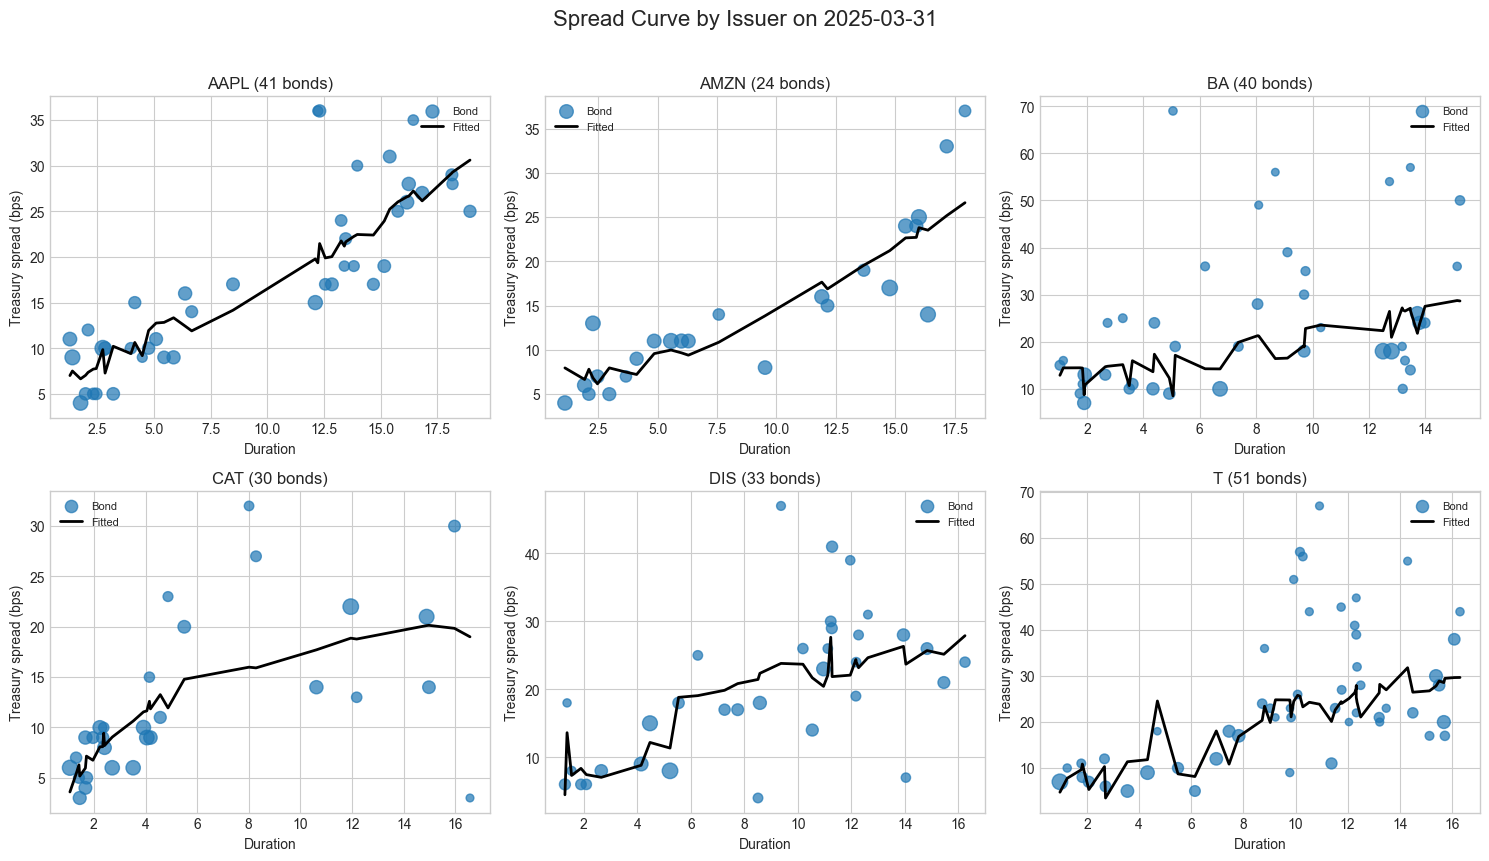

In [9]:
plot_df = fitted[(fitted["DATE"] == analysis_date) & fitted["fit_ok"]].copy()

n_issuers = len(SELECTED_ISSUERS)
ncols = 3
nrows = int(np.ceil(n_issuers / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = plot_df[plot_df["company_symbol"] == issuer].sort_values("DURATION")
    if g.empty:
        ax.set_title(f"{issuer}: no fitted data")
        ax.axis("off")
        continue
    size = np.sqrt(g["T_DVolume_num"].fillna(0).clip(lower=0))
    if size.max() > 0:
        size = 25 + 100 * size / size.max()
    else:
        size = 45
    ax.scatter(g["DURATION"], g["T_Spread_bps"], s=size, alpha=0.70, label="Bond")
    ax.plot(g["DURATION"], g["spread_fit_bps"], color="black", linewidth=2.0, label="Fitted")
    ax.set_title(f"{issuer} ({len(g)} bonds)")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Treasury spread (bps)")
    ax.legend(loc="best", fontsize=8)

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Spread Curve by Issuer on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Rich and Cheap Bonds

Residuals are measured as actual spread minus fitted spread:

- Positive residual: the bond trades wider than the curve and is classified as cheap.
- Negative residual: the bond trades tighter than the curve and is classified as rich.

The table below shows the most extreme residuals on the analysis date.

In [10]:
snapshot = plot_df.copy()
snapshot["rich_cheap"] = np.where(snapshot["resid_bps"] > 0, "cheap", "rich")
outlier_table = (
    snapshot.assign(abs_resid=lambda x: x["resid_bps"].abs())
    .sort_values(["company_symbol", "abs_resid"], ascending=[True, False])
    .groupby("company_symbol")
    .head(6)
    [[
        "company_symbol", "CUSIP", "MATURITY", "SECURITY_LEVEL", "RATING_CAT",
        "COUPON", "DURATION", "TMT", "PRICE_EOM", "T_Spread_bps",
        "spread_fit_bps", "resid_bps", "resid_z", "rich_cheap",
        "T_DVolume_num", "AMOUNT_OUTSTANDING",
    ]]
    .sort_values(["company_symbol", "resid_bps"], ascending=[True, False])
)
display(outlier_table)

,company_symbol,CUSIP,MATURITY,SECURITY_LEVEL,RATING_CAT,COUPON,DURATION,TMT,PRICE_EOM,T_Spread_bps,spread_fit_bps,resid_bps,resid_z,rich_cheap,T_DVolume_num,AMOUNT_OUTSTANDING
1435,AAPL,037833AT7,2044-05-06,SEN,AA,4.4500,12.2300,19.3800,92.2900,36.0000,19.3625,16.6375,3.8620,cheap,"20,807,341.0000","1,000,000.0000"
1460,AAPL,037833EE6,2041-02-08,SEN,AA,2.3750,12.3100,16.0900,70.2400,36.0000,21.4675,14.5325,3.3734,cheap,"79,582,495.0000","1,500,000.0000"
1456,AAPL,037833DZ0,2050-08-20,SEN,AA,2.4000,16.4400,25.7600,59.8700,35.0000,27.2275,7.7725,1.8042,cheap,"28,309,879.0000","1,250,000.0000"
1447,AAPL,037833DD9,2047-09-12,SEN,AA,3.7500,13.9700,22.7800,79.2100,30.0000,22.4623,7.5377,1.7497,cheap,"34,407,947.0000","1,000,000.0000"
1452,AAPL,037833DQ0,2049-09-11,SEN,AA,2.9500,15.4000,24.8100,67.5900,31.0000,25.2360,5.7640,1.3380,cheap,"97,827,660.0000","1,500,000.0000"
1457,AAPL,037833EA4,2060-08-20,SEN,AA,2.5500,18.9400,35.9100,59.0600,25.0000,30.6141,-5.6141,-1.3032,rich,"72,485,993.0000","1,750,000.0000"
2368,AMZN,023135BU9,2060-06-03,SEN,AA,2.7000,17.9400,35.6900,58.0300,37.0000,26.6284,10.3716,2.5791,cheap,"49,920,298.0000","2,000,000.0000"
2372,AMZN,023135CC8,2061-05-12,SEN,AA,3.2500,17.1700,36.6400,65.8200,33.0000,25.1675,7.8325,1.9477,cheap,"104,931,881.0000","1,750,000.0000"
2361,AMZN,023135BC9,2027-08-22,SEN,AA,3.1500,2.2700,2.4300,97.7800,13.0000,6.8327,6.1673,1.5336,cheap,"183,378,367.0000","3,500,000.0000"
2378,AMZN,023135CJ3,2052-04-13,SEN,AA,3.9500,14.7700,27.4300,79.5000,17.0000,21.2109,-4.2109,-1.0471,rich,"259,636,243.0000","2,500,000.0000"


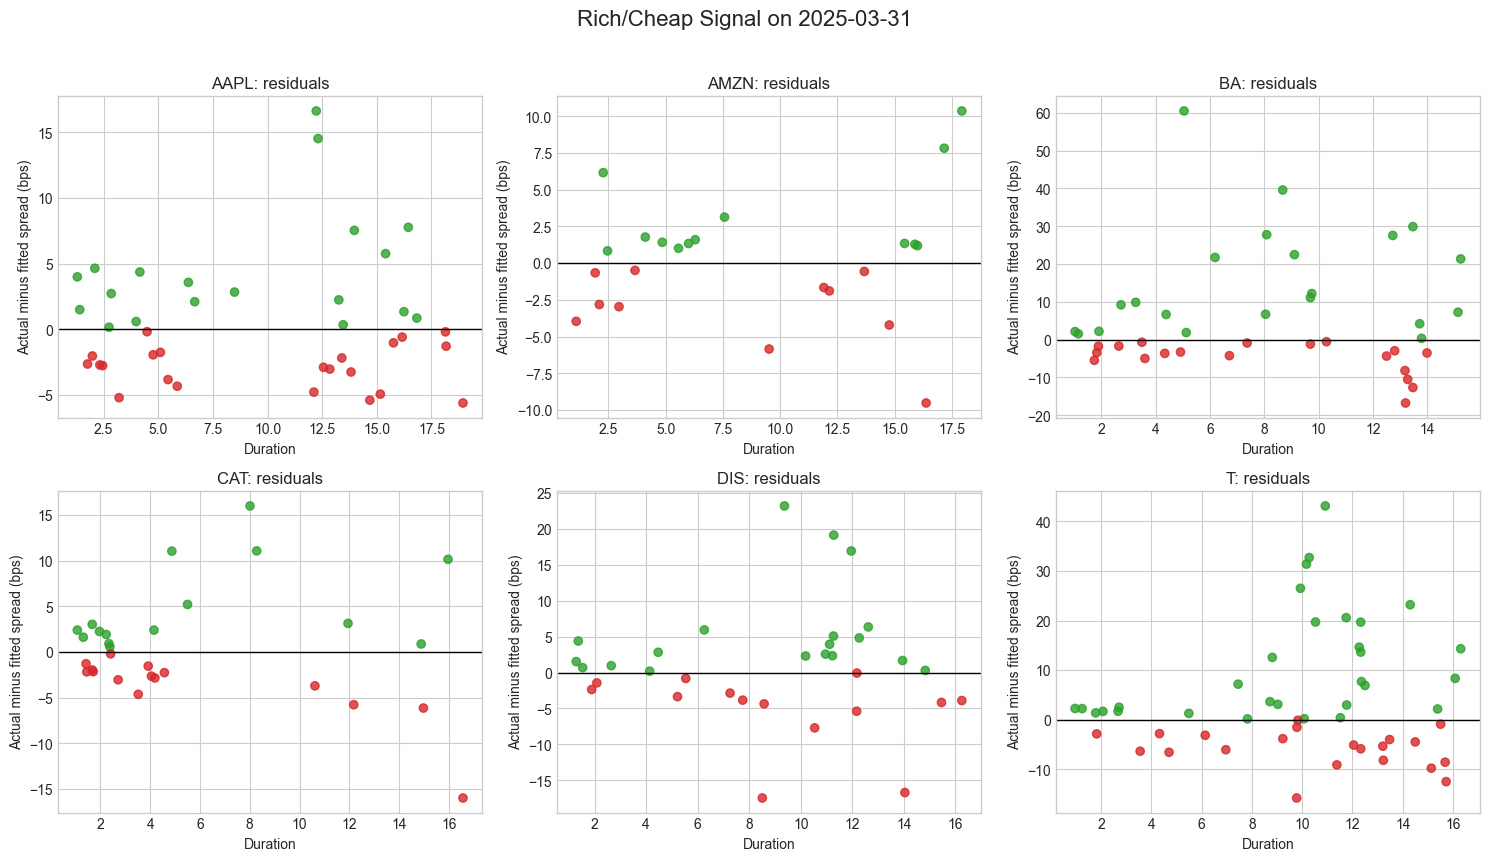

In [11]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = snapshot[snapshot["company_symbol"] == issuer].copy()
    if g.empty:
        ax.axis("off")
        continue
    colors = np.where(g["resid_bps"] >= 0, "tab:green", "tab:red")
    ax.axhline(0, color="black", linewidth=1)
    ax.scatter(g["DURATION"], g["resid_bps"], c=colors, alpha=0.8)
    ax.set_title(f"{issuer}: residuals")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Actual minus fitted spread (bps)")

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Rich/Cheap Signal on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Duration- and DV01-Neutral Portfolio Construction

At each issuer-month:

1. Long the `TOP_N_PER_SIDE` cheapest bonds by residual z-score.
2. Short the `TOP_N_PER_SIDE` richest bonds by residual z-score.
3. Scale the short side so `sum(position * price * duration) = 0`.
4. Normalize gross market value to one for each issuer-month.
5. Evaluate next-month total return and dollar PnL on `GROSS_CAPITAL_USD`.

The signed position is a face-value weight. Since `DV01 = price * duration / 10,000`, the assignment's duration constraint is also a first-order parallel-rate DV01 hedge. It does not neutralize curve slope, curvature, credit beta, or spread-duration differences.

In [12]:
def build_portfolio_one_group(group):
    group = group.dropna(subset=["resid_z", "PRICE_EOM", "DURATION", "next_return"]).copy()
    if len(group) < max(MIN_BONDS_PER_FIT, 2 * TOP_N_PER_SIDE):
        return pd.DataFrame()

    longs = group.nlargest(TOP_N_PER_SIDE, "resid_z").copy()
    shorts = group.nsmallest(TOP_N_PER_SIDE, "resid_z").copy()
    if set(longs.index).intersection(set(shorts.index)):
        return pd.DataFrame()

    longs["side"] = "long cheap"
    shorts["side"] = "short rich"
    port = pd.concat([longs, shorts], axis=0).copy()
    port["raw_signal"] = np.where(port["side"].eq("long cheap"), port["resid_z"].clip(lower=0), (-port["resid_z"]).clip(lower=0))
    port["raw_signal"] = port["raw_signal"].where(port["raw_signal"] > 0, 1.0)

    price_scale = port["PRICE_EOM"] / 100.0
    long_mask = port["side"].eq("long cheap")
    short_mask = ~long_mask
    long_dur = (port.loc[long_mask, "raw_signal"] * price_scale.loc[long_mask] * port.loc[long_mask, "DURATION"]).sum()
    short_dur = (port.loc[short_mask, "raw_signal"] * price_scale.loc[short_mask] * port.loc[short_mask, "DURATION"]).sum()
    if not np.isfinite(long_dur) or not np.isfinite(short_dur) or long_dur <= 0 or short_dur <= 0:
        return pd.DataFrame()

    short_scale = long_dur / short_dur
    port["position_face"] = np.where(long_mask, port["raw_signal"], -port["raw_signal"] * short_scale)
    gross_market_value = (port["position_face"].abs() * price_scale).sum()
    if not np.isfinite(gross_market_value) or gross_market_value <= 0:
        return pd.DataFrame()

    port["position_face"] = port["position_face"] / gross_market_value
    port["market_weight"] = port["position_face"] * price_scale
    port["duration_contribution"] = port["market_weight"] * port["DURATION"]
    port["dv01_usd"] = port["duration_contribution"] * GROSS_CAPITAL_USD / 10_000
    port["return_contribution"] = port["market_weight"] * port["next_return"]
    port["pnl_usd"] = port["return_contribution"] * GROSS_CAPITAL_USD
    return port


position_parts = []
for _, group in fitted.groupby(["company_symbol", "DATE"], sort=True):
    p = build_portfolio_one_group(group)
    if not p.empty:
        position_parts.append(p)

positions = pd.concat(position_parts, ignore_index=True)

issuer_month_returns = (
    positions.groupby(["company_symbol", "DATE"])
    .agg(
        portfolio_return=("return_contribution", "sum"),
        pnl_usd=("pnl_usd", "sum"),
        gross_market_value=("market_weight", lambda x: x.abs().sum()),
        net_market_value=("market_weight", "sum"),
        portfolio_duration=("duration_contribution", "sum"),
        net_dv01_usd=("dv01_usd", "sum"),
        gross_dv01_usd=("dv01_usd", lambda x: x.abs().sum()),
        n_positions=("ISSUE_ID", "size"),
        avg_abs_resid_bps=("resid_bps", lambda x: x.abs().mean()),
    )
    .reset_index()
)

print(f"Built {len(positions):,} bond-month positions across {len(issuer_month_returns):,} issuer-month portfolios.")
display(issuer_month_returns.head())

Built 1,116 bond-month positions across 186 issuer-month portfolios.


,company_symbol,DATE,portfolio_return,pnl_usd,gross_market_value,net_market_value,portfolio_duration,net_dv01_usd,gross_dv01_usd,n_positions,avg_abs_resid_bps
0,AAPL,2022-08-31,-0.0002,-188.8514,1.0000,0.0425,-0.0000,-0.0000,"1,420.9273",6,20.3716
1,AAPL,2022-09-30,-0.0027,"-2,661.6158",1.0000,0.0123,0.0000,0.0000,"1,522.7049",6,24.9512
2,AAPL,2022-10-31,0.0026,"2,582.3383",1.0000,0.0004,0.0000,0.0000,"1,573.5430",6,18.8769
3,AAPL,2022-11-30,-0.0027,"-2,696.0563",1.0000,-0.0350,0.0000,-0.0000,"1,545.0877",6,19.9156
4,AAPL,2022-12-31,-0.0049,"-4,891.2304",1.0000,-0.0917,0.0000,0.0000,"1,575.2520",6,13.7925


In [13]:
def calculate_turnover(pos):
    frames = []
    for issuer, g in pos.groupby("company_symbol"):
        pivot = (
            g.pivot_table(index="DATE", columns="ISSUE_ID", values="market_weight", aggfunc="sum")
            .sort_index()
            .fillna(0.0)
        )
        turnover = 0.5 * pivot.diff().abs().sum(axis=1)
        turnover.iloc[0] = np.nan
        frames.append(pd.DataFrame({"company_symbol": issuer, "DATE": turnover.index, "turnover": turnover.values}))
    return pd.concat(frames, ignore_index=True)


turnover = calculate_turnover(positions)
issuer_month_returns = issuer_month_returns.merge(turnover, on=["company_symbol", "DATE"], how="left")

combined_returns = (
    issuer_month_returns
    .groupby("DATE")
    .agg(
        portfolio_return=("portfolio_return", "mean"),
        pnl_usd=("pnl_usd", "mean"),
        turnover=("turnover", "mean"),
        portfolio_duration=("portfolio_duration", "mean"),
        net_dv01_usd=("net_dv01_usd", "mean"),
        issuers=("company_symbol", "nunique"),
    )
    .reset_index()
)

for cost_bps in TRANSACTION_COST_BPS:
    combined_returns[f"net_return_{cost_bps}bps"] = (
        combined_returns["portfolio_return"] - combined_returns["turnover"].fillna(0) * cost_bps / 10_000
    )

display(issuer_month_returns.tail())
display(combined_returns.tail())

,company_symbol,DATE,portfolio_return,pnl_usd,gross_market_value,net_market_value,portfolio_duration,net_dv01_usd,gross_dv01_usd,n_positions,avg_abs_resid_bps,turnover
181,T,2024-10-31,-0.0025,"-2,509.9233",1.0000,-0.0085,0.0000,0.0000,"1,321.6761",6,31.3086,1.0000
182,T,2024-11-30,-0.0083,"-8,265.6279",1.0000,-0.2275,0.0000,0.0000,"1,026.5258",6,30.2647,0.7749
183,T,2024-12-31,-0.0085,"-8,463.7060",1.0000,-0.1163,0.0000,0.0000,943.1681,6,31.8765,0.7450
184,T,2025-01-31,0.0003,314.8636,1.0000,-0.2611,-0.0000,-0.0000,701.4344,6,31.7125,0.6700
185,T,2025-02-28,-0.0073,"-7,258.6336",1.0000,0.0284,0.0000,0.0000,"1,052.5328",6,32.0253,0.8772


,DATE,portfolio_return,pnl_usd,turnover,portfolio_duration,net_dv01_usd,issuers,net_return_0bps,net_return_10bps,net_return_25bps,net_return_50bps
26,2024-10-31,0.0006,587.7291,0.8766,0.0000,0.0000,6,0.0006,-0.0003,-0.0016,-0.0038
27,2024-11-30,0.0000,19.7362,0.8276,-0.0000,-0.0000,6,0.0000,-0.0008,-0.0020,-0.0041
28,2024-12-31,-0.0002,-242.5565,0.8573,0.0000,0.0000,6,-0.0002,-0.0011,-0.0024,-0.0045
29,2025-01-31,-0.0009,-943.9985,0.7835,-0.0000,0.0000,6,-0.0009,-0.0017,-0.0029,-0.0049
30,2025-02-28,0.0708,"70,823.8853",0.7655,-0.0000,-0.0000,6,0.0708,0.0701,0.0689,0.0670


## Performance, PnL, and Trading-Cost Sensitivity

Gross returns are next-month long-short returns on a portfolio with unit gross market value. Dollar PnL is shown for `$1,000,000` of gross capital. The combined portfolio equal-weights the available issuer portfolios each month while keeping total gross capital at `$1,000,000`.

Because the lecture notes emphasize that corporate-bond trading costs can be comparable to strategy returns, net results subtract one-way costs of 10, 25, and 50 basis points multiplied by monthly one-way turnover. Financing, borrow fees, and failed shorts remain unmodeled.

In [14]:
def performance_summary(return_series):
    r = pd.Series(return_series).dropna()
    if r.empty:
        return pd.Series(dtype=float)
    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (12 / len(r)) - 1 if len(r) > 0 else np.nan
    ann_vol = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else np.nan
    sharpe = ann_return / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol > 0 else np.nan
    return pd.Series({
        "months": len(r),
        "mean_monthly_return": r.mean(),
        "monthly_volatility": r.std(ddof=1),
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "annualized_sharpe": sharpe,
        "total_return": total_return,
        "win_rate": (r > 0).mean(),
    })


issuer_summary = issuer_month_returns.groupby("company_symbol")["portfolio_return"].apply(performance_summary).unstack()
issuer_extras = issuer_month_returns.groupby("company_symbol").agg(
    total_pnl_usd=("pnl_usd", "sum"),
    avg_turnover=("turnover", "mean"),
    avg_abs_portfolio_duration=("portfolio_duration", lambda x: x.abs().mean()),
    avg_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().mean()),
    avg_positions=("n_positions", "mean"),
)
issuer_summary = issuer_summary.join(issuer_extras)

combined_summary = performance_summary(combined_returns["portfolio_return"]).to_frame("combined").T
combined_summary["total_pnl_usd"] = combined_returns["pnl_usd"].sum()
combined_summary["avg_turnover"] = combined_returns["turnover"].mean()
combined_summary["avg_abs_portfolio_duration"] = combined_returns["portfolio_duration"].abs().mean()
combined_summary["avg_abs_net_dv01_usd"] = combined_returns["net_dv01_usd"].abs().mean()
combined_summary["avg_positions"] = issuer_month_returns.groupby("DATE")["n_positions"].sum().mean()

summary_table = pd.concat([issuer_summary, combined_summary], axis=0)
display(summary_table.style.format({
    "mean_monthly_return": "{:.2%}", "monthly_volatility": "{:.2%}",
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}",
    "win_rate": "{:.1%}", "total_pnl_usd": "${:,.0f}",
    "avg_turnover": "{:.2f}", "avg_abs_portfolio_duration": "{:.6f}",
    "avg_abs_net_dv01_usd": "${:,.4f}", "avg_positions": "{:.1f}",
}))

cost_sensitivity = pd.DataFrame({
    f"{cost} bps": performance_summary(combined_returns[f"net_return_{cost}bps"])
    for cost in TRANSACTION_COST_BPS
}).T
display(cost_sensitivity[["annualized_return", "annualized_volatility", "annualized_sharpe", "total_return", "win_rate"]].style.format({
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}", "win_rate": "{:.1%}",
}))

,months,mean_monthly_return,monthly_volatility,annualized_return,annualized_volatility,annualized_sharpe,total_return,win_rate,total_pnl_usd,avg_turnover,avg_abs_portfolio_duration,avg_abs_net_dv01_usd,avg_positions
AAPL,31.000000,1.32%,7.50%,14.13%,25.98%,0.54,40.71%,54.8%,"$410,142",0.84,0.000000,$0.0000,6.0
AMZN,31.000000,-0.02%,0.21%,-0.27%,0.72%,-0.38,-0.70%,48.4%,"$-6,979",0.79,0.000000,$0.0000,6.0
BA,31.000000,0.09%,0.47%,1.02%,1.63%,0.62,2.64%,51.6%,"$26,435",0.74,0.000000,$0.0000,6.0
CAT,31.000000,-0.02%,0.97%,-0.32%,3.35%,-0.10,-0.82%,51.6%,"$-6,845",0.74,0.000000,$0.0000,6.0
DIS,31.000000,0.10%,0.39%,1.24%,1.36%,0.91,3.24%,64.5%,"$32,144",0.82,0.000000,$0.0000,6.0
T,31.000000,-0.06%,0.75%,-0.78%,2.61%,-0.30,-1.99%,41.9%,"$-19,283",0.77,0.000000,$0.0000,6.0
combined,31.000000,0.23%,1.29%,2.75%,4.47%,0.62,7.27%,51.6%,"$72,602",0.78,0.000000,$0.0000,36.0


,annualized_return,annualized_volatility,annualized_sharpe,total_return,win_rate
0 bps,2.75%,4.47%,0.62,7.27%,51.6%
10 bps,1.82%,4.47%,0.41,4.78%,38.7%
25 bps,0.45%,4.46%,0.10,1.16%,25.8%
50 bps,-1.81%,4.46%,-0.41,-4.60%,9.7%


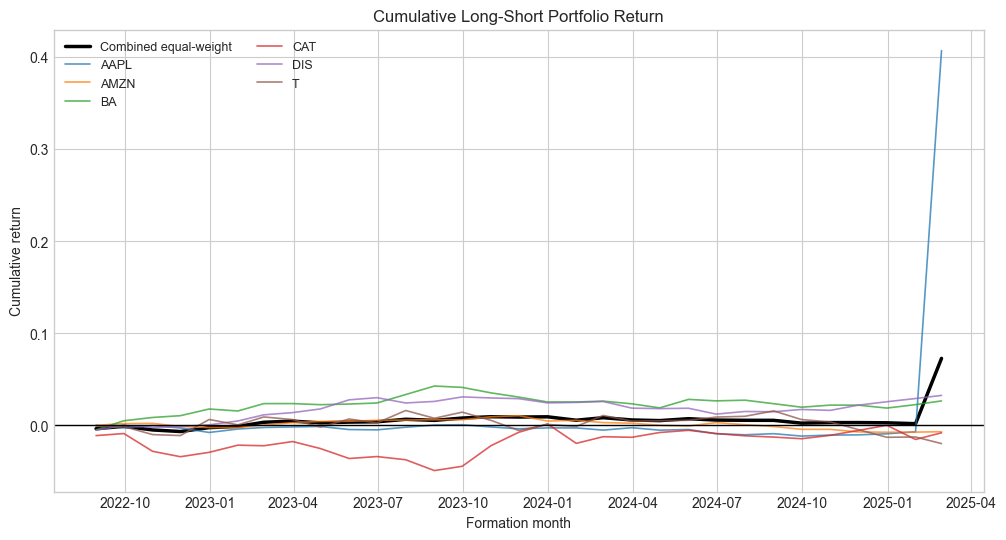

In [15]:
cumulative = combined_returns[["DATE", "portfolio_return"]].copy()
cumulative["combined"] = (1 + cumulative["portfolio_return"]).cumprod() - 1

issuer_cum = issuer_month_returns.pivot(index="DATE", columns="company_symbol", values="portfolio_return").sort_index()
issuer_cum = (1 + issuer_cum).cumprod() - 1

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cumulative["DATE"], cumulative["combined"], color="black", linewidth=2.5, label="Combined equal-weight")
for issuer in SELECTED_ISSUERS:
    if issuer in issuer_cum.columns:
        ax.plot(issuer_cum.index, issuer_cum[issuer], linewidth=1.2, alpha=0.75, label=issuer)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Cumulative Long-Short Portfolio Return")
ax.set_xlabel("Formation month")
ax.set_ylabel("Cumulative return")
ax.legend(ncol=2, fontsize=9)
plt.show()

## Turnover and DV01 Neutrality Checks

The first-order hedge is verified in both duration-contribution units and dollars of DV01 for `$1,000,000` gross capital. Values near zero are expected up to floating-point precision. Gross DV01 is nonzero; the purpose of the long-short scaling is to make the signed net DV01 approximately zero.

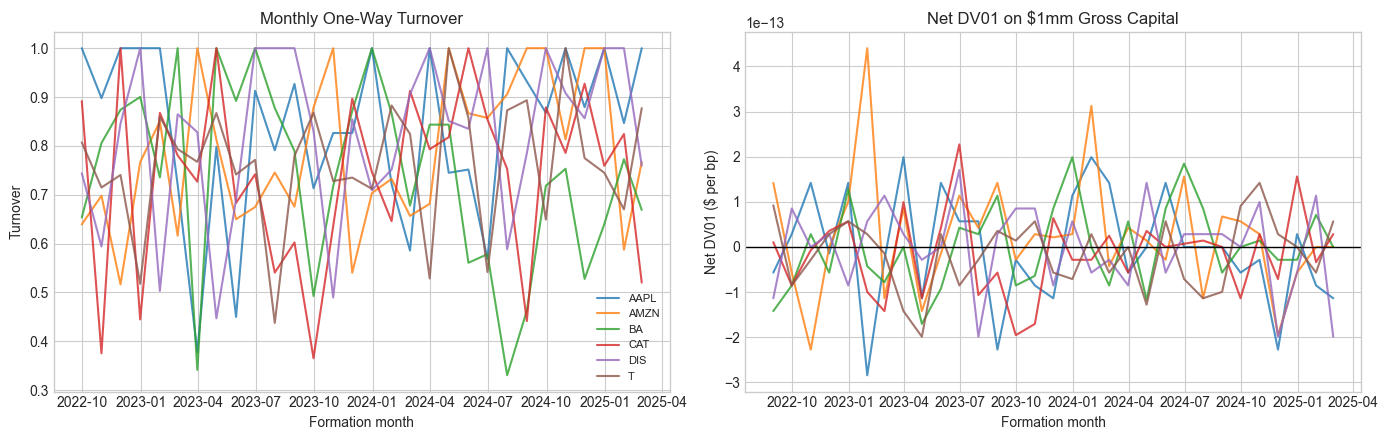

,max_abs_net_dv01_usd,avg_abs_net_dv01_usd,avg_gross_dv01_usd,avg_turnover
company_symbol,,,,
AAPL,$0.000000,$0.000000,"$1,490",0.84
AMZN,$0.000000,$0.000000,"$1,404",0.79
BA,$0.000000,$0.000000,"$1,036",0.74
CAT,$0.000000,$0.000000,"$1,066",0.74
DIS,$0.000000,$0.000000,"$1,101",0.82
T,$0.000000,$0.000000,"$1,022",0.77


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[0].plot(g["DATE"], g["turnover"], alpha=0.8, label=issuer)
axes[0].set_title("Monthly One-Way Turnover")
axes[0].set_xlabel("Formation month")
axes[0].set_ylabel("Turnover")
axes[0].legend(fontsize=8)

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[1].plot(g["DATE"], g["net_dv01_usd"], alpha=0.8, label=issuer)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Net DV01 on $1mm Gross Capital")
axes[1].set_xlabel("Formation month")
axes[1].set_ylabel("Net DV01 ($ per bp)")

fig.tight_layout()
plt.show()

display(
    issuer_month_returns.groupby("company_symbol").agg(
        max_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().max()),
        avg_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().mean()),
        avg_gross_dv01_usd=("gross_dv01_usd", "mean"),
        avg_turnover=("turnover", "mean"),
    ).style.format({
        "max_abs_net_dv01_usd": "${:,.6f}", "avg_abs_net_dv01_usd": "${:,.6f}",
        "avg_gross_dv01_usd": "${:,.0f}", "avg_turnover": "{:.2f}",
    })
)

## Systematic Outlier Review

The lecture notes warn that apparent mispricing can reflect issue characteristics rather than convergence alpha: liquidity, issue size, age, coupon structure, optionality, seniority, or different issuer entities. The first table identifies repeatedly selected bonds. The second compares all selected rich/cheap observations with the rest of the fitted universe on characteristics available in WRDS.

This is descriptive, not causal. A persistent residual associated with low trading volume or small issue size is evidence of a liquidity channel and should make the trade less convincing, not more.

In [17]:
selection_review = (
    positions.assign(
        cheap_count=lambda x: (x["side"] == "long cheap").astype(int),
        rich_count=lambda x: (x["side"] == "short rich").astype(int),
        abs_resid_bps=lambda x: x["resid_bps"].abs(),
    )
    .groupby(["company_symbol", "CUSIP", "BOND_TYPE", "MATURITY", "COUPON"])
    .agg(
        times_selected=("ISSUE_ID", "size"),
        times_cheap=("cheap_count", "sum"),
        times_rich=("rich_count", "sum"),
        avg_duration=("DURATION", "mean"),
        avg_spread_bps=("T_Spread_bps", "mean"),
        avg_abs_resid_bps=("abs_resid_bps", "mean"),
        median_dvolume=("T_DVolume_num", "median"),
        median_amount_outstanding=("AMOUNT_OUTSTANDING", "median"),
        avg_bond_age_years=("bond_age_years", "mean"),
    )
    .reset_index()
    .sort_values(["times_selected", "avg_abs_resid_bps"], ascending=False)
    .head(20)
)
display(selection_review)

fitted_review = fitted[fitted["fit_ok"]].copy()
selected_keys = positions[["company_symbol", "DATE", "ISSUE_ID", "side"]].drop_duplicates()
fitted_review = fitted_review.merge(selected_keys, on=["company_symbol", "DATE", "ISSUE_ID"], how="left")
fitted_review["selection_group"] = fitted_review["side"].fillna("not selected")

characteristic_comparison = fitted_review.groupby("selection_group").agg(
    observations=("ISSUE_ID", "size"),
    median_abs_residual_bps=("resid_bps", lambda x: x.abs().median()),
    median_dollar_volume=("T_DVolume_num", "median"),
    median_amount_outstanding=("AMOUNT_OUTSTANDING", "median"),
    median_bond_age_years=("bond_age_years", "median"),
    median_duration=("DURATION", "median"),
    median_tmt=("TMT", "median"),
    median_coupon=("COUPON", "median"),
)
display(characteristic_comparison)

,company_symbol,CUSIP,BOND_TYPE,MATURITY,COUPON,times_selected,times_cheap,times_rich,avg_duration,avg_spread_bps,avg_abs_resid_bps,median_dvolume,median_amount_outstanding,avg_bond_age_years
134,DIS,25468PCX2,CMTN,2042-12-01,3.7000,22,7,15,12.6055,22.3182,26.7071,"4,273,828.0000","500,000.0000",11.0790
94,CAT,149123CD1,CDEB,2044-05-15,4.3000,20,8,12,13.0030,34.3500,25.0766,"8,593,985.5000","500,000.0000",9.4556
90,CAT,149123BL4,CDEB,2035-09-15,5.3000,20,15,5,8.5720,37.3000,20.9496,"4,695,931.0000","307,320.0000",18.4940
49,AMZN,023135CK0,CDEB,2062-04-13,4.1000,20,11,9,17.2340,40.1500,12.6317,"75,032,527.0000","1,250,000.0000",1.5547
89,CAT,149123BJ9,CDEB,2031-05-01,7.3000,19,12,7,5.7605,39.8421,30.3281,"1,102,774.0000","242,226.0000",22.5458
91,CAT,149123BN0,CDEB,2036-08-15,6.0500,18,15,3,8.8672,45.4444,24.8831,"15,374,747.5000","460,060.0000",17.3584
95,CAT,149123CE9,CDEB,2064-05-15,4.7500,18,6,12,16.7939,30.1667,20.6919,"6,887,964.5000","500,000.0000",9.6973
43,AMZN,023135CC8,CDEB,2061-05-12,3.2500,18,8,10,17.9817,36.3889,12.7587,"44,004,423.0000","1,750,000.0000",2.7064
167,T,00209AAF3,CDEB,2031-03-01,8.7500,17,1,16,5.3024,17.5294,33.2989,"558,912.0000","228,894.0000",22.4591
65,BA,097023BV6,CDEB,2047-03-01,3.6500,16,9,7,13.6019,61.5625,53.8182,"941,877.0000","300,000.0000",6.6807


,observations,median_abs_residual_bps,median_dollar_volume,median_amount_outstanding,median_bond_age_years,median_duration,median_tmt,median_coupon
selection_group,,,,,,,,
long cheap,558,23.9946,"18,992,211.0000","526,886.0000",6.3039,12.3250,19.0150,4.2500
not selected,6443,3.9084,"51,311,024.0000","1,100,000.0000",4.2765,6.7500,8.0700,3.6000
short rich,558,13.1561,"28,339,152.0000","1,000,000.0000",4.5024,13.1500,22.7650,4.1250


## Findings

The cell below generates a submission-ready interpretation directly from the executed results. It separates mechanical backtest evidence from implementation caveats emphasized in the lecture notes.

In [18]:
combined = summary_table.loc["combined"]
best_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmax()
worst_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmin()
avg_duration_error = issuer_month_returns["portfolio_duration"].abs().mean()
avg_net_dv01 = issuer_month_returns["net_dv01_usd"].abs().mean()
avg_turnover = issuer_month_returns["turnover"].mean()
ret_source_share = filtered["next_return_source"].value_counts(normalize=True).to_dict()
ret_eom_share = ret_source_share.get("RET_EOM", 0.0)
cost_25 = cost_sensitivity.loc["25 bps"]

outlier_liquidity = characteristic_comparison.loc[[x for x in ["long cheap", "short rich", "not selected"] if x in characteristic_comparison.index], "median_dollar_volume"]
liquidity_sentence = "The available outlier-characteristic table should be used to judge whether repeated signals are concentrated in less-liquid or smaller issues."
if {"long cheap", "not selected"}.issubset(outlier_liquidity.index):
    direction = "lower" if outlier_liquidity["long cheap"] < outlier_liquidity["not selected"] else "higher"
    liquidity_sentence = f"Long-cheap observations have {direction} median reported dollar volume than non-selected observations, so liquidity is a plausible component of the residual signal and deserves trade-level review."

finding_text = f"""
### Summary Write-up

The analysis uses {', '.join(SELECTED_ISSUERS)} from {START_DATE} through {END_DATE}. In line with the lecture's grouping framework, each issuer-month retains a common seniority and rating category. The calibration sample also excludes defaulted and convertible bonds, requires at least {MIN_TMT_YEARS:.0f} year to maturity, and requires approximately ${MIN_AMOUNT_OUTSTANDING * 1_000 / 1_000_000:,.0f} million outstanding.

The issuer curve uses log-duration, duration, and coupon, estimated by weighted least squares. TRACE dollar volume and amount outstanding receive greater weight because the lecture identifies active, large issues as more reliable price observations. Wider-than-fitted bonds are classified as cheap; tighter-than-fitted bonds are rich. {liquidity_sentence}

The monthly strategy buys the three cheapest and shorts the three richest bonds for each issuer. Scaling makes the signed market-value duration contribution approximately zero. On ${GROSS_CAPITAL_USD:,.0f} gross capital, the average absolute net DV01 is only ${avg_net_dv01:,.6f} per basis point, confirming that the first-order parallel-rate hedge works mechanically.

For the equal-weighted combined issuer portfolio, gross total return is {combined['total_return']:.2%}, annualized return is {combined['annualized_return']:.2%}, annualized volatility is {combined['annualized_volatility']:.2%}, and annualized Sharpe ratio is {combined['annualized_sharpe']:.2f}. Gross cumulative dollar PnL across monthly observations is ${combined['total_pnl_usd']:,.0f} on the stated $1 million gross-capital convention. Average one-way monthly turnover is {avg_turnover:.2f}. At a 25 bp one-way transaction-cost assumption, annualized return falls to {cost_25['annualized_return']:.2%} and Sharpe falls to {cost_25['annualized_sharpe']:.2f}. This gap is economically important because the lecture notes stress that trading costs and shorting frictions can absorb short-horizon credit RV returns.

Among issuers, {best_issuer} has the strongest gross Sharpe ratio and {worst_issuer} the weakest. {ret_eom_share:.1%} of filtered bond-month observations have a valid next-month WRDS `RET_EOM`. The documented price-plus-accrual fallback was available but was not needed for this sample; the remaining observations lack a valid next-month record. The result is best interpreted as a sanity check for mean reversion, not a fully executable trading simulation: bid-offer spreads, borrow availability, financing, fill probability, callable structure, and point-in-time data availability are not fully modeled.
"""

display(Markdown(finding_text))


### Summary Write-up

The analysis uses AAPL, AMZN, BA, CAT, DIS, T from 2022-08-31 through 2025-03-31. In line with the lecture's grouping framework, each issuer-month retains a common seniority and rating category. The calibration sample also excludes defaulted and convertible bonds, requires at least 1 year to maturity, and requires approximately $200 million outstanding.

The issuer curve uses log-duration, duration, and coupon, estimated by weighted least squares. TRACE dollar volume and amount outstanding receive greater weight because the lecture identifies active, large issues as more reliable price observations. Wider-than-fitted bonds are classified as cheap; tighter-than-fitted bonds are rich. Long-cheap observations have lower median reported dollar volume than non-selected observations, so liquidity is a plausible component of the residual signal and deserves trade-level review.

The monthly strategy buys the three cheapest and shorts the three richest bonds for each issuer. Scaling makes the signed market-value duration contribution approximately zero. On $1,000,000 gross capital, the average absolute net DV01 is only $0.000000 per basis point, confirming that the first-order parallel-rate hedge works mechanically.

For the equal-weighted combined issuer portfolio, gross total return is 7.27%, annualized return is 2.75%, annualized volatility is 4.47%, and annualized Sharpe ratio is 0.62. Gross cumulative dollar PnL across monthly observations is $72,602 on the stated $1 million gross-capital convention. Average one-way monthly turnover is 0.78. At a 25 bp one-way transaction-cost assumption, annualized return falls to 0.45% and Sharpe falls to 0.10. This gap is economically important because the lecture notes stress that trading costs and shorting frictions can absorb short-horizon credit RV returns.

Among issuers, DIS has the strongest gross Sharpe ratio and AMZN the weakest. 95.6% of filtered bond-month observations have a valid next-month WRDS `RET_EOM`. The documented price-plus-accrual fallback was available but was not needed for this sample; the remaining observations lack a valid next-month record. The result is best interpreted as a sanity check for mean reversion, not a fully executable trading simulation: bid-offer spreads, borrow availability, financing, fill probability, callable structure, and point-in-time data availability are not fully modeled.


## Main Assumptions and Limitations

- **Return convention:** `RET_EOM` is treated as WRDS's preferred monthly total return. The fallback approximates dirty-price economics with clean-price change plus coupon accrual using actual gap days over 360; it does not reconstruct the full coupon schedule.
- **Point-in-time availability:** the notebook assumes the month-end fields were observable when positions were formed. It does not model publication delays or data revisions.
- **Curve specification:** the three-factor linear model is transparent and assignment-compliant, but it is not a full Nelson-Siegel cash-flow model and does not explicitly model the Treasury zero curve.
- **Instrument heterogeneity:** seniority, rating, default status, convertibility, maturity, and issue size are controlled. Complete callable/puttable schedules, 144A/Reg S status, subsidiary distinctions, insurance, and step-up coupons are unavailable in the supplied files.
- **Risk neutrality:** the portfolio neutralizes first-order parallel-rate DV01 only. It can retain Treasury-curve slope/curvature risk, spread-duration risk, issuer beta, downgrade risk, and liquidity exposure.
- **Implementation costs:** turnover-based cost scenarios are illustrative. Actual bid-offer spreads, market impact, financing, borrow fees, locate availability, and failed fills may be larger and asymmetric.
- **Selection and overfitting:** issuers, thresholds, model, and cost assumptions are fixed for clarity but are not validated on a separate holdout sample. Reported performance should be interpreted as in-sample evidence.
- **Shorting feasibility:** corporate bonds can be expensive or impossible to borrow. The symmetric long-short backtest is a research construct, not proof of implementability.